In [220]:
from utils import *
from utils.new_custom_classes import ParameterField
from utils.sigmav_functions import *
import numpy as np
import matplotlib.pyplot as plt
import itertools
import plotly.graph_objects as go
from tqdm import tqdm
from scipy.integrate import solve_ivp

import pandas as pd
import seaborn as sns

# Parametrization points

In [221]:
# generic number of values for each parameter used for the parametric analysis
param_points = 3
# Number of points for the spatial distribution of parameters
space_points = 1

# OPTIONAL - if not specified, the time necessary to reach a 50%D-50%T concentration in the plasma will be calculated
# total time for the parametric analysis [s]
total_time = 5* u.d

# Parameters

### Plasma parameters

In [222]:
# Basic parameter fields (no time or spatial dependence)
V_plasma_field = ParameterField(
    parametrization_type="normal", mean=150, std=15, unit=u.m**3, 
    param_points=1, name="plasma_volume"
)

tau_p_T_field = ParameterField(
    parametrization_type="linear", min_val = 1, max_val=10, unit=u.s,
    param_points=1, name="tau_p_T"
)

tau_p_He3_field = ParameterField(
    parametrization_type="normal", mean=1, std=0.5, unit=u.s,
    param_points=1, name="tau_p_He3"
)


############################################################################## IN PRINCIPLE COULD BE t-dependent
P_aux_field = ParameterField(
    parametrization_type="linear", min_val=20, max_val=100, unit=u.MW,
    param_points=1, name="P_aux"
)

P_lost_rad_field = ParameterField(
    parametrization_type="linear", min_val=0, max_val=20, unit=u.MW,
    param_points=1, name="P_lost_rad"
)

P_aux_all_DT_field = ParameterField(
    parametrization_type="linear", min_val=20, max_val=100, unit=u.MW,
    param_points=1, name="P_aux"
)

P_lost_rad_all_DT_field = ParameterField(
    parametrization_type="linear", min_val=0, max_val=20, unit=u.MW,
    param_points=1, name="P_lost_rad"
)

print("Basic parameter fields created:")
print(f"V_plasma: {V_plasma_field}")
print(f"tau_p_T: {tau_p_T_field}")
print(f"tau_p_He3: {tau_p_He3_field}")
print(f"P_aux: {P_aux_field}")
print(f"P_aux_all_DT: {P_aux_all_DT_field}")
print(f"P_lost_rad: {P_lost_rad_field}")
print(f"P_lost_rad_all_DT: {P_lost_rad_all_DT_field}")

Basic parameter fields created:
V_plasma: <ParameterField 'plasma_volume' type=normal, profile=none, shape=(1,), unit=meter ** 3>
[150.000] meter ** 3
tau_p_T: <ParameterField 'tau_p_T' type=linear, profile=none, shape=(1,), unit=second>
[5.500] second
tau_p_He3: <ParameterField 'tau_p_He3' type=normal, profile=none, shape=(1,), unit=second>
[1.000] second
P_aux: <ParameterField 'P_aux' type=linear, profile=none, shape=(1,), unit=megawatt>
[60.000] megawatt
P_aux_all_DT: <ParameterField 'P_aux' type=linear, profile=none, shape=(1,), unit=megawatt>
[60.000] megawatt
P_lost_rad: <ParameterField 'P_lost_rad' type=linear, profile=none, shape=(1,), unit=megawatt>
[10.000] megawatt
P_lost_rad_all_DT: <ParameterField 'P_lost_rad' type=linear, profile=none, shape=(1,), unit=megawatt>
[10.000] megawatt


##### Spataial parameters (pedestal profile)

In [223]:
# Create spatial parameter fields for temperature and density
T_i_spatial = ParameterField(
    parametrization_type="normal",
    spatial_profile="pedestal",
    mean=14, std=1, unit=u.keV,
    param_points=1,
    space_points=space_points,
    value_center=1.0,        # Relative to mean
    value_ped=0.22,          # 5.5 keV / 25 keV ≈ 0.22
    value_edge=0.0004,       # 0.01 keV / 25 keV ≈ 0.0004
    transition_ratio=0.95,
    name="T_i_spatial"
)

n_tot_spatial = ParameterField(
    parametrization_type="normal",
    spatial_profile="pedestal", 
    mean=1.7e20, std=1e19, unit=u.m**(-3),
    param_points=1,
    space_points=space_points,
    value_center=1.0,        # Relative to mean
    value_ped=0.67,          # 1.45e20 / 2.15e20 ≈ 0.67
    value_edge=0.047,        # 1e19 / 2.15e20 ≈ 0.047
    transition_ratio=0.95,
    name="n_tot_spatial"
)

print("Spatial parameter fields:")
print(f"T_i_spatial: {T_i_spatial}")
print(f"n_tot_spatial: {n_tot_spatial}")


Spatial parameter fields:
T_i_spatial: <ParameterField 'T_i_spatial' type=normal, profile=pedestal, shape=(1,), unit=kiloelectron_volt>
[14.000] kiloelectron_volt
n_tot_spatial: <ParameterField 'n_tot_spatial' type=normal, profile=pedestal, shape=(1,), unit=1 / meter ** 3>
[170000000000000000000.000] 1 / meter ** 3


##### Fuel Injection function

### Breeding and inventory parameters

In [224]:
TBR_DT_field = ParameterField(
    parametrization_type="linear", min_val=1.05, max_val=1.15,
    param_points=1, name="TBR_DT"
)

TBR_DDn_field = ParameterField(
    parametrization_type="linear", min_val=0.5, max_val=0.7,
    param_points=1, name="TBR_DDn"
)

tau_ifc_field = ParameterField(
    parametrization_type="linear", min_val=1, max_val=24, unit=u.h,
    param_points=1, name="tau_ifc"
)

tau_ofc_field = ParameterField(
    parametrization_type="linear", min_val=1, max_val=48, unit=u.h,
    param_points=1, name="tau_ofc"
)



print("Breeding parameters:")
print(f"TBR_DT: {TBR_DT_field}")
print(f"TBR_DDn: {TBR_DDn_field}")
print(f"tau_ifc: {tau_ifc_field}")
print(f"tau_ofc: {tau_ofc_field}")

Breeding parameters:
TBR_DT: <ParameterField 'TBR_DT' type=linear, profile=none, shape=(1,), unit=dimensionless>
[1.100] dimensionless
TBR_DDn: <ParameterField 'TBR_DDn' type=linear, profile=none, shape=(1,), unit=dimensionless>
[0.600] dimensionless
tau_ifc: <ParameterField 'tau_ifc' type=linear, profile=none, shape=(1,), unit=hour>
[12.500] hour
tau_ofc: <ParameterField 'tau_ofc' type=linear, profile=none, shape=(1,), unit=hour>
[24.500] hour


### Energy production parameters

In [225]:
# Economic parameters
eta_th_field = ParameterField(
    parametrization_type="linear", min_val=0.3, max_val=0.4,
    param_points=1, name="eta_th"
)

plant_avail_field = ParameterField(
    parametrization_type="linear", min_val=0.7, max_val=0.9,
    param_points=1, name="plant_availability"
)

Cost_per_kWh_field = ParameterField(
    parametrization_type="normal", mean=0.25, std=0.1, unit=1/u.kWh,
    param_points=1, name="Cost_per_kWh"
)

print("Economic parameters:")
print(f"eta_th: {eta_th_field}")
print(f"plant_avail: {plant_avail_field}")
print(f"Cost_per_kWh: {Cost_per_kWh_field}")

Economic parameters:
eta_th: <ParameterField 'eta_th' type=linear, profile=none, shape=(1,), unit=dimensionless>
[0.350] dimensionless
plant_avail: <ParameterField 'plant_availability' type=linear, profile=none, shape=(1,), unit=dimensionless>
[0.800] dimensionless
Cost_per_kWh: <ParameterField 'Cost_per_kWh' type=normal, profile=none, shape=(1,), unit=1 / kilowatt_hour>
[0.250] 1 / kilowatt_hour


# Perform the parametric analysis

In [226]:
input_data = [
    V_plasma_field.data,
    tau_p_T_field.data, 
    tau_p_He3_field.data,
    P_aux_field.data,
    P_lost_rad_field.data,
    P_aux_all_DT_field.data,
    P_lost_rad_all_DT_field.data,
    
    T_i_spatial.data,
    n_tot_spatial.data,
    
    TBR_DT_field.data,
    TBR_DDn_field.data,
    tau_ifc_field.data,
    tau_ofc_field.data,
    
    eta_th_field.data,
    plant_avail_field.data,
    Cost_per_kWh_field.data,
]


In [227]:

# Create iterator based only on the number of parameter variations (first dimension)
param_ranges = [range(data.shape[0]) for data in input_data]

results = []

def injection_rate_fun(t, N_ifc, N_st, n_T, N_st_min = 0.001/tritium_mass.to('kg').magnitude):
    # set injection rate so that satisfies these constraints:
    # - if N_st < N_st_min, injection_rate = 0
    # - else, injection_rate = N_ifc/tau_ifc - lambda_T*N_st (tries to inject all the T that enters the storage)
    # - maximum injection rate is injection_rate_max = n_T50/tau_p_T*V_plasma + Tdot_burn5050 - T_dot_DDp5050 (the injection rate necessary to maintain a 50D50T plasma)
    injection_rate_max = (n_tot/2/tau_p_T*V_plasma + 0.25*n_tot**2*sigmav_DT*V_plasma - 0.25/2*n_tot**2*sigmav_DD_p*V_plasma).to('1/s')
    if N_st < N_st_min:
        return 0 * u.s**(-1)
    else:
        return min((N_ifc/tau_ifc - lambda_T*N_st), injection_rate_max).to('1/s')

def tritium_inventory_odes(t,y):
    N_ofc, N_ifc, N_st = y[0], y[1], y[2]
    """
    n_spatial = n_tot.size  # or set explicitly
    n_T = np.array(y[3:3+n_spatial])  # shape (n_spatial,)
    n_T = n_T/u.m**3"""
    n_T = y[3]/u.m**3
    n_D = n_tot - n_T
    
    injection_rate = injection_rate_fun(t, N_ifc, N_st, n_T)    
    
    Tdot_DDn = (TBR_DDn*0.5*n_D**2*sigmav_DD_n*V_plasma).to('1/s')
    Tdot_DDp = (0.5*n_D**2*sigmav_DD_p*V_plasma).to('1/s')
    Tdot_DT = (TBR_DT*n_D*n_T*sigmav_DT*V_plasma).to('1/s')
    Tdot_burn = (n_D*n_T*sigmav_DT*V_plasma).to('1/s')

    dN_ofc_dt = (Tdot_DT + Tdot_DDn - N_ofc / tau_ofc - N_ofc*lambda_T).to('1/s')
    dN_ifc_dt = (N_ofc / tau_ofc - N_ifc / tau_ifc  - lambda_T * N_ifc + n_T/tau_p_T*V_plasma).to('1/s')
    dN_stor_dt = (N_ifc / tau_ifc - lambda_T * N_st - injection_rate).to('1/s')
    dnT_dt = (injection_rate/V_plasma + Tdot_DDp/V_plasma - n_T/tau_p_T - Tdot_burn/V_plasma).to('1/s/m^3')

    total_T_produced = (Tdot_DDn + Tdot_DDp + Tdot_DT).to('1/s')
    total_T_burnt = (n_D*n_T*sigmav_DT*V_plasma).to('1/s')

    net_T_produced = total_T_produced - total_T_burnt

    return [float(dN_ofc_dt.to('1/s').magnitude), float(dN_ifc_dt.to('1/s').magnitude), float(dN_stor_dt.to('1/s').magnitude), float(dnT_dt.to('1/s/m^3').magnitude)]

    
def DT_reached(t, y):
    # Get tritium profile from y
    n_spatial = n_tot.size
    n_T = np.array(y[3:3+n_spatial])
    # Integrate tritium over space (use sum or trapz if you have spatial grid)
    total_tritium = np.sum(n_T)
    # Integrate total inventory over space
    total_n_tot = np.sum(n_tot.magnitude)
    # Stop when total tritium reaches 50% of total inventory
    return total_tritium - 0.5 * total_n_tot

def NEGATIVE(t, y):
    # stop when y[0] or y[1] or y[2] or y[3] is negative
    return min(y[0]+1e-10, y[1]+1e-10, y[2]+1e-10, y[3]+1e-10)

# Time span
t_span = (0, total_time.to('s').magnitude)
t_eval = np.linspace(*t_span, 1000)
    
for param_combo in tqdm(itertools.product(*param_ranges), 
                       total=np.prod([data.shape[0] for data in input_data]), 
                       desc="Parametric analysis"):
    
    # Extract data for each parameter
    extracted_data = [input_data[i][param_idx] for i, param_idx in enumerate(param_combo)]
        
    # Unpack the extracted data
    (V_plasma, tau_p_T, tau_p_He3, P_aux, P_lost_rad, P_aux_all_DT, P_lost_rad_all_DT,
     T_i, n_tot,
     
     TBR_DT, TBR_DDn, tau_ifc, tau_ofc,
     
     eta_th, plant_avail, Cost_per_kWh,
     ) = extracted_data


    # Get cross-sections
    sigmav_DD = sigmav_DD_BoschHale(T_i)[0].to('m^3/s')  # [m^3/s]
    sigmav_DD_p = sigmav_DD_BoschHale(T_i)[1].to('m^3/s')  # [m^3/s]
    sigmav_DD_n = sigmav_DD_BoschHale(T_i)[2].to('m^3/s')  # [m^3/s]
    sigmav_DT = sigmav_DT_BoschHale(T_i).to('m^3/s')    # [m^3/s]
    sigmav_DHe3 = sigmav_DHe3_BoschHale(T_i).to('m^3/s')   # [m^3/s]
    
    y0 = np.zeros(3 + n_tot.size)  # Initial conditions: [N_ofc, N_ifc, N_st, n_T]


    # stop whe  DT reached
    DT_reached.terminal = True
    NEGATIVE.terminal = True
    # Solve ODE
    sol = solve_ivp(
        fun = tritium_inventory_odes, 
        t_span = t_span, 
        t_eval = t_eval,
        y0 = y0, 
        method = 'BDF', 
        dense_output=False,
        events = [DT_reached, NEGATIVE], )
    
    if sol.t_events[1].size > 0:
        print(f"Negative event occurred at t={sol.t_events[1]}")
        break
    elif sol.t_events[0].size > 0:
        t_startup = sol.t_events[0][0]*u.s
    else:
        t_startup = np.inf*u.s
        
    # calculate the energy produced
    n_T = sol.y[3] * u.m**(-3)  # shape (n_spatial, n_time)
    if np.ndim(n_tot) == 0 or (hasattr(n_tot, "shape") and n_tot.shape == ()):
        n_D = n_tot * np.ones_like(n_T) - n_T
    else:
        n_D = n_tot[:, np.newaxis] - n_T  # shape (n_spatial, n_time)

    P_DDn = n_D*n_D*sigmav_DD_n/2*V_plasma*E_DDn
    P_DDp = n_D*n_D*sigmav_DD_p/2*V_plasma*E_DDp
    P_DT = n_D*n_T*sigmav_DT*V_plasma*E_DT

    # equivalent energy if always DT
    P_DT_full = n_tot/2*n_tot/2*sigmav_DT*V_plasma*E_DT
    
    # energy lost
    # Integrate over time (up to t_startup if not infinite, else total_time)
    t_end = t_startup.to('s').magnitude if np.isfinite(t_startup.to('s').magnitude) else total_time.to('s').magnitude
    mask = sol.t <= t_end

    net_energy_DD = np.trapz((P_DDn[mask]+P_DDp[mask]+P_DT[mask]-P_lost_rad*np.ones(sol.t[mask].shape))-P_aux*np.ones(sol.t[mask].shape), sol.t[mask]*u.s)
    net_energy_DT_full = np.trapz((P_DT_full-P_lost_rad_all_DT)*np.ones(sol.t[mask].shape)-P_aux_all_DT*np.ones(sol.t[mask].shape), sol.t[mask]*u.s)

    E_lost = eta_th*(net_energy_DT_full-net_energy_DD)

    Dollar_Lost = E_lost * Cost_per_kWh
    
    n_T = sol.y[3] * u.m**(-3)
    I_ifc = sol.y[0] * tritium_mass.to('kg')
    I_ofc = sol.y[1] * tritium_mass.to('kg')
    I_stor = sol.y[2] * tritium_mass.to('kg')
    row = [
        # INPUTS
        V_plasma.to('m^3').magnitude,                     # 0
        tau_p_T.to('s').magnitude,                      # 1
        tau_p_He3.to('s').magnitude,                    # 2
        P_aux.to('MW').magnitude,               # 3
        P_aux_all_DT.to('MW').magnitude,        # 4
        P_lost_rad.to('MW').magnitude,          # 5
        P_lost_rad_all_DT.to('MW').magnitude,   # 6
        T_i.to('keV').magnitude,                          # 7
        n_tot.to('m^-3').magnitude,                        # 8
        #injection_rate_max.magnitude,           # -
        TBR_DT.magnitude if hasattr(TBR_DT, "magnitude") else TBR_DT,  # 9
        TBR_DDn.magnitude if hasattr(TBR_DDn, "magnitude") else TBR_DDn,  # 10
        tau_ifc.magnitude if hasattr(tau_ifc, "magnitude") else tau_ifc,  # 11
        tau_ofc.magnitude if hasattr(tau_ofc, "magnitude") else tau_ofc,  # 12
        eta_th.magnitude if hasattr(eta_th, "magnitude") else eta_th,  # 13
        plant_avail.magnitude if hasattr(plant_avail, "magnitude") else plant_avail,  # 14
        Cost_per_kWh.to('1/kWh').magnitude,                 # 15
        # OUTPUTS
        P_DT.to('MW'),                          # 16
        P_DDn.to('MW'),                         # 17
        P_DDp.to('MW'),                         # 18
        P_DT_full.to('MW'),                     # 19
        t_startup.to('hour'),         # 20
        E_lost.to('MJ'),              # 21
        Dollar_Lost.to(''),                  # 22
        n_T,                                    # 23
        I_ifc,                                  # 24
        I_ofc,                                  # 25
        I_stor                                  # 26
    ]
    results.append(row)

Parametric analysis:   0%|          | 0/1 [00:00<?, ?it/s]

Parametric analysis: 100%|██████████| 1/1 [00:01<00:00,  1.07s/it]


In [228]:
print("Parametric analysis completed.")
for i, row in enumerate(results):
    print(f"Case {i+1}:")
    print("  INPUTS:")
    print(f"    V_plasma           = {row[0]:.3g} m^3")
    print(f"    tau_p_T            = {row[1]:.3g} s")
    print(f"    tau_p_He3          = {row[2]:.3g} s")
    print(f"    P_aux              = {row[3]:.3g} MW")
    print(f"    P_aux_all_DT       = {row[4]:.3g} MW")
    print(f"    P_lost_rad         = {row[5]:.3g} MW")
    print(f"    P_lost_rad_all_DT  = {row[6]:.3g} MW")
    print(f"    T_i                = {row[7]:.3g} keV")
    print(f"    n_tot              = {row[8]:.3g} m^-3")
    print(f"    TBR_DT             = {row[9]:.3g}")
    print(f"    TBR_DDn            = {row[10]:.3g}")
    print(f"    tau_ifc            = {row[11]:.3g} h")
    print(f"    tau_ofc            = {row[12]:.3g} h")
    print(f"    eta_th             = {row[13]:.3g}")
    print(f"    plant_avail        = {row[14]:.3g}")
    print(f"    Cost_per_kWh       = {row[15]:.3g} 1/kWh")
    print("  OUTPUTS:")
    print(f"    P_DT               = {row[16]:.3g} MW")
    print(f"    P_DDn              = {row[17]:.3g} MW")
    print(f"    P_DDp              = {row[18]:.3g} MW")
    print(f"    P_DT_full          = {row[19].to('MW').magnitude:.3g} MW")
    print(f"    t_startup          = {row[20]:.3g} h")
    print(f"    E_lost             = {row[21]:.3g} MJ")
    print(f"    Dollar_Lost        = {row[22]/1e6:.3g} M$")
    print(f"    n_T                = {row[23]:.3g}")
    print(f"    I_ifc_final        = {row[24]:.3g}")
    print(f"    I_ofc_final        = {row[25]:.3g}")
    print(f"    I_stor_final       = {row[26]:.3g}")
    print("-" * 40)

Parametric analysis completed.
Case 1:
  INPUTS:
    V_plasma           = 150 m^3
    tau_p_T            = 5.5 s
    tau_p_He3          = 1 s
    P_aux              = 60 MW
    P_aux_all_DT       = 60 MW
    P_lost_rad         = 10 MW
    P_lost_rad_all_DT  = 10 MW
    T_i                = 14 keV
    n_tot              = 1.7e+20 m^-3
    TBR_DT             = 1.1
    TBR_DDn            = 0.6
    tau_ifc            = 12.5 h
    tau_ofc            = 24.5 h
    eta_th             = 0.35
    plant_avail        = 0.8
    Cost_per_kWh       = 0.25 1/kWh
  OUTPUTS:
    P_DT               = [0 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.35 1.3

/home/alessmor/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1345: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


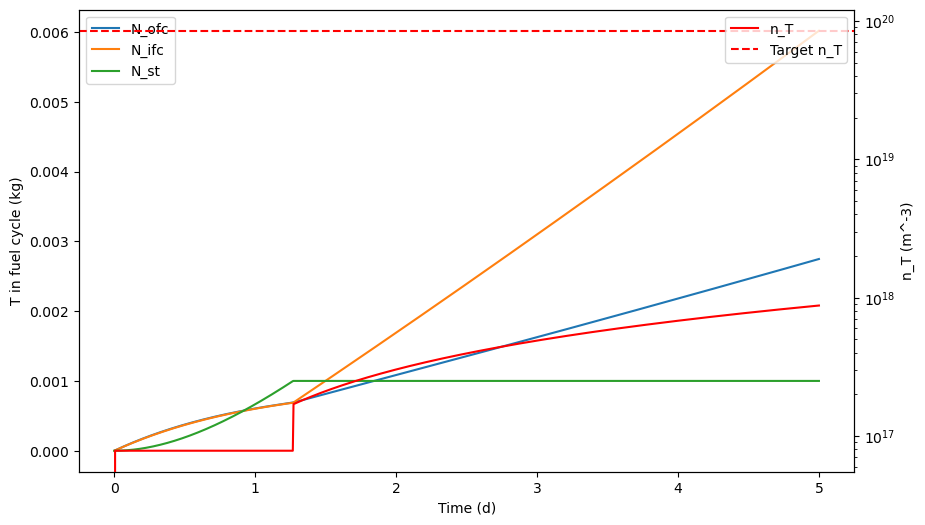

In [ ]:
# plot the evolution of the solutions of solveivp
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each solution
for i in range(sol.y.shape[0]):
    if i == 0:
        ax.plot(sol.t/(3600*24), sol.y[i] * tritium_mass.to('kg'), label="N_ofc")
    elif i == 1:
        ax.plot(sol.t/(3600*24), sol.y[i] * tritium_mass.to('kg'), label="N_ifc")
    elif i == 2:
        ax.plot(sol.t/(3600*24), sol.y[i] * tritium_mass.to('kg'), label="N_st")
    elif i == 3:
        # plot n_T with another axis
        ax2 = ax.twinx()
        ax2.plot(sol.t/(3600*24), sol.y[i], label="n_T", color='red')
        # plot a target horizontal line at n_tot/2
        #ax2.axhline(y=row[8]/2, color='red', linestyle='--', label="Target n_T")
        ax2.set_ylabel("n_T (m^-3)")
        ax2.legend(loc="upper right")
        ax2.set_yscale("log")

# Add labels and title
ax.set_xlabel("Time (d)")
ax.set_ylabel("T in fuel cycle (kg)")
ax.set_title("")
ax.legend()

# Show the plot
plt.show()


/tmp/ipykernel_22344/804758215.py:17: RuntimeWarning: divide by zero encountered in divide
  Tdot_burn.magnitude / injection_rate_magnitude,
/tmp/ipykernel_22344/804758215.py:17: RuntimeWarning: invalid value encountered in divide
  Tdot_burn.magnitude / injection_rate_magnitude,


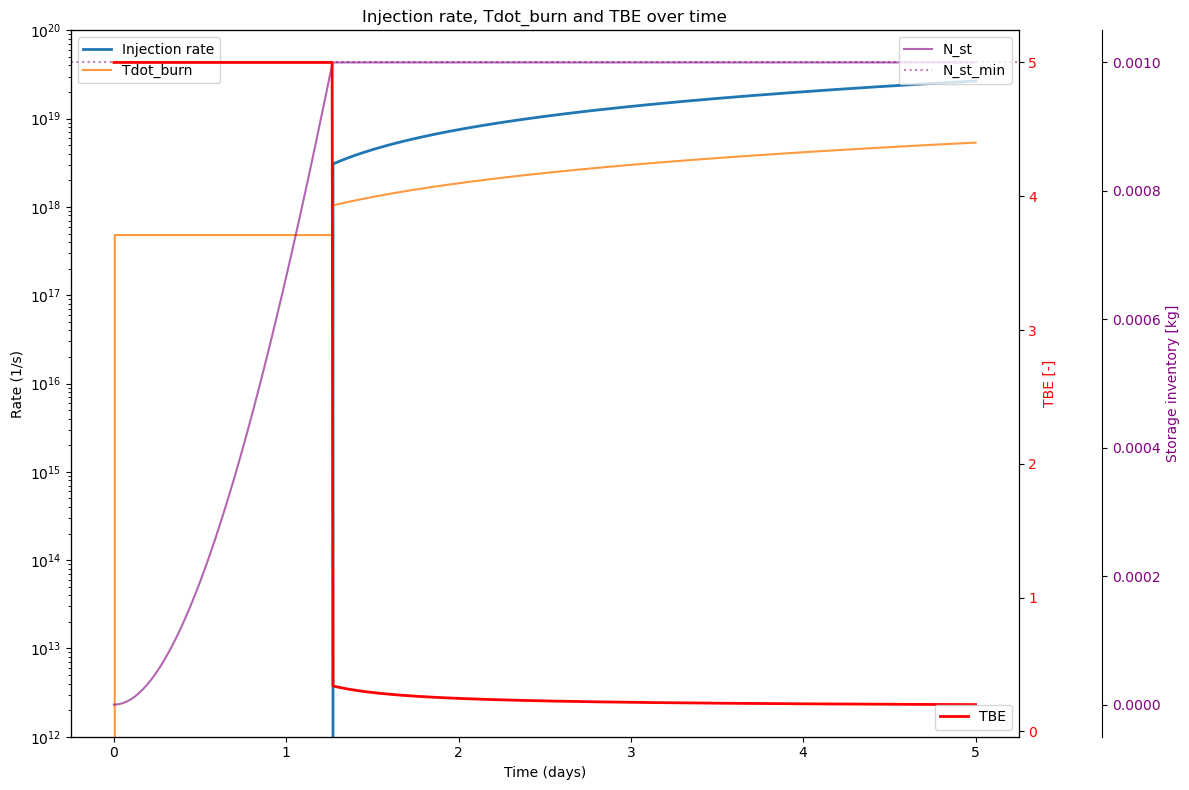

=== INJECTION RATE ANALYSIS ===
Injection rate range: 0.00e+00 to 2.67e+19 1/s
Tritium burn rate range: 0.00e+00 to 5.36e+18 1/s
Storage inventory range: 0.00e+00 kilogram to 1.00e-03 kilogram
Storage threshold: 1.00e-03
Injection becomes active at t = 1.27 days


In [230]:
# calculate injected T over time using the ACTUAL injection rate from the ODE
n_T = sol.y[3] * u.m**(-3)
n_D = n_tot*np.ones_like(n_T) - n_T
N_ofc = sol.y[0]
N_ifc = sol.y[1]  
N_st = sol.y[2]

# Correct list comprehension syntax
injection_rate = [injection_rate_fun(time*u.s, particles_ifc, particles_st, density_T).to('1/s').magnitude 
                  for time, particles_ifc, particles_st, density_T in zip(sol.t, N_ifc, N_st, n_T)] * u.s**(-1)

Tdot_burn = (n_D*n_T*sigmav_DT*V_plasma).to('1/s')

# Handle division by zero for TBE calculation
injection_rate_magnitude = injection_rate.magnitude
TBE = np.where(injection_rate_magnitude > 1e-20, 
               Tdot_burn.magnitude / injection_rate_magnitude, 
               np.inf)

# plot injection rate, Tdot_burn and Tdot_burn/injection_rate = TBE (on different axis) over time 
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(sol.t/(3600*24), injection_rate.magnitude, label="Injection rate", linewidth=2)
ax.plot(sol.t/(3600*24), Tdot_burn.magnitude, label="Tdot_burn", alpha=0.8)

# Add storage inventory on third y-axis
N_st_min = 0.001 # kg
ax3 = ax.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(sol.t/(3600*24), N_st* tritium_mass.to('kg').magnitude, label="N_st", color='purple', alpha=0.6)
ax3.axhline(y=N_st_min, color='purple', linestyle=':', alpha=0.5, label=f"N_st_min")
ax3.set_ylabel("Storage inventory [kg]", color='purple')
ax3.tick_params(axis='y', labelcolor='purple')

# TBE on second y-axis
ax2 = ax.twinx()
ax2.plot(sol.t/(3600*24), np.clip(TBE, 0, 5), label="TBE", color='red', linewidth=2)
ax2.set_ylabel("TBE [-]", color='red')
#ax2.set_ylim(0, 2)
ax2.tick_params(axis='y', labelcolor='red')

# Format main axis
ax.set_xlabel("Time (days)")
ax.set_ylabel("Rate (1/s)")
ax.set_yscale("log")
ax.set_ylim(1e12, 1e20)
ax.set_title("Injection rate, Tdot_burn and TBE over time")
ax.legend(loc="upper left")
ax2.legend(loc="lower right")
ax3.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Print summary statistics
print("=== INJECTION RATE ANALYSIS ===")
print(f"Injection rate range: {np.min(injection_rate.magnitude):.2e} to {np.max(injection_rate.magnitude):.2e} 1/s")
print(f"Tritium burn rate range: {np.min(Tdot_burn.magnitude):.2e} to {np.max(Tdot_burn.magnitude):.2e} 1/s")
print(f"Storage inventory range: {np.min(N_st*tritium_mass.to('kg')):.2e} to {np.max(N_st*tritium_mass.to('kg')):.2e}")
print(f"Storage threshold: {N_st_min:.2e}")

# Check when injection becomes active
active_injection_idx = np.where(injection_rate.magnitude > 1e-15)[0]
if active_injection_idx.size > 0:
    first_active = active_injection_idx[0]
    print(f"Injection becomes active at t = {sol.t[first_active]/(24*3600):.2f} days")
else:
    print("No significant injection occurs during simulation")